# Overfitting and Underfitting in Decision Trees

##  Introduction

Overfitting and Underfitting are common problems in machine learning models, including Decision Trees.  
They occur when the model is either too simple to capture patterns in the data or too complex and learns noise from the training data.

Understanding these concepts is important to build models that generalize well to unseen data.

---

##  Underfitting

Underfitting occurs when the model is too simple to learn the underlying patterns in the dataset.

In Decision Trees, this usually happens when:
- The tree depth is very small
- The model has very few splits

### Characteristics
- High bias
- Low variance
- Poor performance on both training and test data

### Example
A decision tree with **depth = 1 or 2** may not capture complex relationships in the dataset.

---

## Overfitting

Overfitting occurs when the model learns the training data too well, including noise and irrelevant patterns.

In Decision Trees, this happens when:
- The tree grows very deep
- The model memorizes the training data

### Characteristics
- Low training error
- High test error
- High variance

### Example
A decision tree with **very large depth** may create too many splits and fit every training point perfectly.

---

##  Bias–Variance Tradeoff

| Model Complexity | Problem | Bias | Variance |
|------------------|--------|------|---------|
| Very Simple Tree | Underfitting | High | Low |
| Balanced Tree | Good Model | Moderate | Moderate |
| Very Deep Tree | Overfitting | Low | High |

---

##  How to Prevent Overfitting in Decision Trees

Common techniques include:

- Limiting **max_depth**
- Setting **min_samples_split**
- Setting **min_samples_leaf**
- Using **max_features**
- Applying **pruning**

These techniques help control the complexity of the decision tree and improve generalization.

---

##  Objective of This Notebook

In this notebook, we will:

- Train Decision Tree models with different depths
- Observe underfitting and overfitting behavior
- Compare training and testing performance
- Visualize the effect of model complexity

### Import requirements 

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.tree import DecisionTreeClassifier

### Make a function for changing depth of tree 

In [4]:
def analyze(max_depth):
    # Load dataset
    data = pd.read_csv('Social_Network_Ads.csv')
    
    # Selecting features and target
    X = data.iloc[:, 2:4].values      # Age, Estimated Salary
    y = data.iloc[:, -1].values       # Purchased (0/1)
    
    # Creating model with given max_depth
    clf = DecisionTreeClassifier(max_depth=max_depth)
    clf.fit(X, y)

    # Creating a meshgrid for decision boundary
    a =np.linspace(X[:,0].min()-1,X[:,0].max()+1,300)
    b =np.linspace(X[:,0].min()-1,X[:,0].max()+1,300)
    XX, yy = np.meshgrid(a, b)
    
    # Prepare input grid for prediction
    input_array = np.array([XX.ravel(), yy.ravel()]).T
    labels = clf.predict(input_array)

    # Plot the contour (decision boundary)
    plt.contourf(XX, yy, labels.reshape(XX.shape), alpha=0.4)
    
    # Plot actual data points
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black')
    plt.title(f"Decision Tree (max_depth = {max_depth})")
    plt.xlabel("Age")
    plt.ylabel("Estimated Salary")
    plt.show()

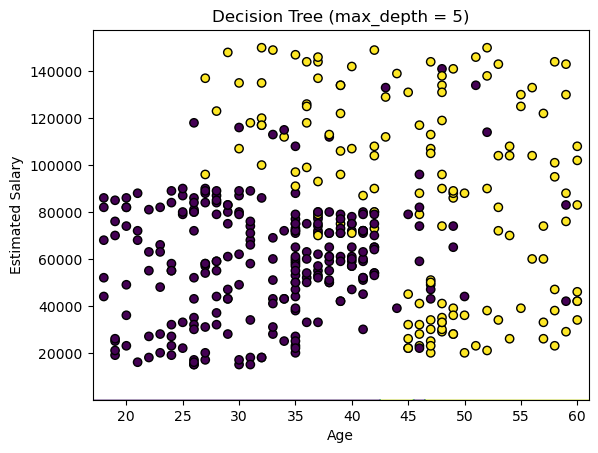

In [5]:
# Example: Try different depths to see underfitting/overfitting
analyze(5)   # Full tree (overfitting)
# analyze(1)
# analyze(2)
# analyze(3)
# analyze(4)
# analyze(5)


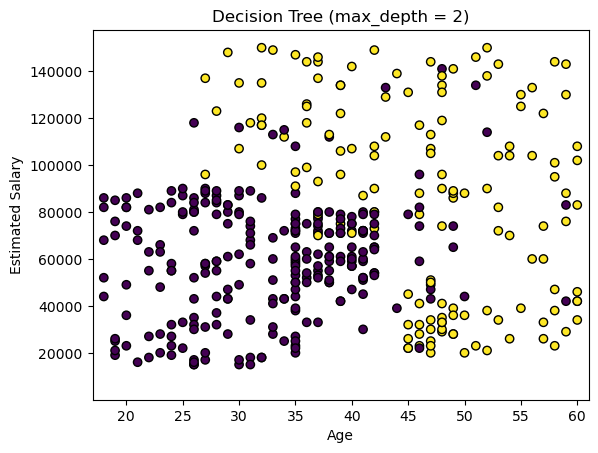

In [6]:
analyze(2)